In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import requests
from typing import Annotated
from pydantic import BaseModel, ConfigDict, Field
from typing import Literal
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage

C:\Users\dell\AppData\Local\Temp\ipykernel_1684\3654504748.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [3]:
# coding , google_search, weather

# Stat
class FlowState(BaseModel):
    question: str = Field(description="The question being asked")
    category: Literal["coding", "google_search", "weather"] = Field(default="google_search", 
                                                                    description="The category of the question")
    answer: str = Field(default="", description="The answer to the question")
    messages: Annotated[list[AnyMessage], add_messages] = Field(default_factory=list)
    

In [4]:
class QuestionCategory(BaseModel):
    model_config = ConfigDict(extra="forbid")
    category: Literal["coding", "google_search", "weather"] = Field(description="The category of the question")

In [5]:
llmGroq = ChatGroq(model="openai/gpt-oss-20b")

> Define your agents

In [6]:
# google agent
googleSearch = GoogleSerperAPIWrapper()
tools = [googleSearch.run]

google_agent = create_agent(
    model = llmGroq,
    tools = tools,
    system_prompt = "You are a helpful assistant that uses Google Search to answer questions."
)


# weather agent
weather_api_key = os.getenv("OPENWEATHER_API_KEY")
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    # Insert your weather API call here (e.g., OpenWeatherMap)
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={weather_api_key}&units=metric"
    response = requests.get(url).json()
    temp = response['main']['temp']
    desc = response['weather'][0]['description']
    return f"The temperature in {city} is {temp}°C with {desc}."

weather_agent = create_agent(
    model = llmGroq,
    tools = [get_weather],
    system_prompt = "You are a helpful assistant that provides current weather information for a given city."
)

In [7]:
def check_question_category(state: FlowState):
    category_llm = llmGroq.with_structured_output(
        QuestionCategory,
        method="json_schema",
        strict=True,
    )
    result = category_llm.invoke([
        SystemMessage(content=(
            "Classify the latest user message as coding, google_search, or weather. "
            "Return valid json with a category field. Use earlier messages to resolve follow-ups."
        )),
        *state.messages,
    ])
    return {"category": result.category}

In [8]:
# flow = FlowState(question="What is the temperature of Pune?")
# # flow = FlowState(question="What is arr[0] == 5")
# check_question_category(flow)
# print(flow)

In [9]:
def route(state: FlowState) -> Literal[
    "google_search", 
    "weather", 
    "coding"]:
    return state.category

In [10]:
""" In coding node ChatGroq.invoke receives a list directly, so the system message and history must be in one flat list
Without *, the history would be nested as one list inside another, rather than a sequence of messages.
The * only expands the list for this LLM call; it doesn't modify or save"""

def coding_node(state: FlowState):
    print("[coding_node] message received: ", state.messages[-1].content)
    result = llmGroq.invoke([
        SystemMessage(content="You are a coding expert."),
        *state.messages,
    ])
    answer = result.content
    return {
        "answer": answer,
        "messages": [AIMessage(content=answer)],
    }

In [11]:
def weather_node(state: FlowState):
    print("[weather_node] message received: ", state.messages[-1].content)

    result = weather_agent.invoke({"messages": state.messages})

    answer = result["messages"][-1].content
    return {
        "answer": answer,
        "messages": [AIMessage(content=answer)],
    }

In [12]:
def google_search_node(state: FlowState):
    print("[google_search_node] message received: ", state.messages[-1].content)
    result = google_agent.invoke({"messages": state.messages})
    answer = result["messages"][-1].content

    if isinstance(answer, list):
        answer = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in answer
        )

    return {
        "answer": answer,
        "messages": [AIMessage(content=answer)],
    }

In [13]:
memory = InMemorySaver()

In [14]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("google_search", google_search_node)
graph.add_node("weather", weather_node)
graph.add_node("coding", coding_node)


# Only use string names for nodes. LangGraph expects strings for node references.
graph.add_edge(START, "check_question_category") # not! (START, check_question_category)
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("google_search", END)
graph.add_edge("weather", END)
graph.add_edge("coding", END)

graph = graph.compile(checkpointer=memory)

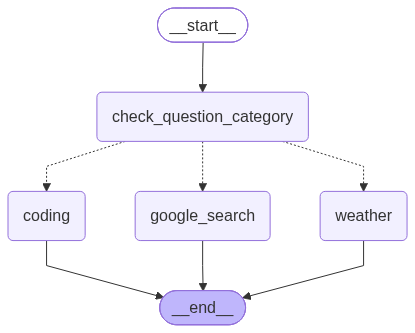

In [15]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [16]:
while True:
    query = input("user: ")
    print("user: ", query)
    if query.lower() in ["bye", "exit", "quit"]:
        print("Good bye")
        break

    result = graph.invoke(
        {
            "question": query,
            "messages": [HumanMessage(content=query)],
        },
        {"configurable": {"thread_id": "5drteuykloip684099hm5op6bh5rtg54"}},
    )

    # answer = result["messages"][-1].content
    answer = result["answer"]
    print("ai: ", answer , "\n")

user:  hi
[google_search_node] message received:  hi
ai:  Hello! How can I help you today? 

user:  who is president of india
[google_search_node] message received:  who is president of india
ai:  The current President of India is **Droupadi Murmu**. She assumed office on 25 July 2022 as the 15th President of the Republic of India. 

user:  and prime minister
[google_search_node] message received:  and prime minister
ai:  The Prime Minister of India is **Narendra Modi**. He has been serving in that role since May 26, 2014. 

user:  how is the weather in capital
[weather_node] message received:  how is the weather in capital
ai:  In New Delhi (the capital), it’s currently about **35 °C** with a clear, sunny sky. Let me know if you’d like details for a different city or time! 

user:  what this == operator is about in brief
[coding_node] message received:  what this == operator is about in brief
ai:  The `==` operator is the **equality comparison operator** used in many programming langu